# Comparison of visium HD and scRNA-seq

Activate sopa_env_kernel

In [1]:
import spatialdata
import sopa

import spatialdata_plot

import scanpy as sc

from __future__ import annotations

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import os

/pasteur/appa/homes/npont/miniconda3/envs/sopa_env/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/pasteur/appa/homes/npont/miniconda3/envs/sopa_env/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## Load visium HD data

embryo head data (A1 or D1) segmented using sopa workflow

**LATER TRY ALSO WITH THE SEGMENTED VERSION FROM SEGMENTATION/STARDIST (supposed to be similar a sopa uses stardist, but it also uses patches segmentation)**

In [2]:
sdata_A1 = spatialdata.read_zarr("data/embryo_head_A1_segmented.zarr")
sdata_D1 = spatialdata.read_zarr("data/embryo_head_D1_segmented.zarr") 

version mismatch: detected: RasterFormatV02, requested: FormatV04
/pasteur/appa/homes/npont/miniconda3/envs/sopa_env/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/pasteur/appa/homes/npont/miniconda3/envs/sopa_env/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/pasteur/appa/homes/npont/miniconda3/envs/sopa_env/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/pasteur/appa/homes/npont/miniconda3/envs/sopa_env/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/pasteur/appa/homes/npont/

In [3]:
# Table containing the aggregated counts of each 2 micron bins into each segmented cell
sdata_A1["table"]

# n_obs x n_vars = n_cells x n_genes

AnnData object with n_obs × n_vars = 166530 × 18085
    obs: 'region', 'slide', 'cell_id', 'area'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'sopa_attrs', 'spatialdata_attrs'
    obsm: 'bins_assignments', 'spatial'

In [4]:
sdata_D1["table"]

AnnData object with n_obs × n_vars = 151885 × 18085
    obs: 'region', 'slide', 'cell_id', 'area'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'sopa_attrs', 'spatialdata_attrs'
    obsm: 'bins_assignments', 'spatial'

In [5]:
adata_A1 = sdata_A1["table"]
adata_D1 = sdata_D1["table"]

In [6]:
## Average counts per cell ##

# I sum the counts for each cell across all genes
total_counts_per_cell_A1 = adata_A1.X.sum(axis=1)
total_counts_per_cell_D1 = adata_D1.X.sum(axis=1)

# I compute the mean of sums across all cells
avg_counts_per_cell_A1 = total_counts_per_cell_A1.mean() 
avg_counts_per_cell_D1 = total_counts_per_cell_D1.mean()

print(f"Average counts per cell in A1: {avg_counts_per_cell_A1:.2f}")
print(f"Average counts per cell in D1: {avg_counts_per_cell_D1:.2f}")

Average counts per cell in A1: 627.41
Average counts per cell in D1: 723.28


In [7]:
## Average nb of unique features per cell ##

# I get the nb of non zero entries for each cell
total_unique_genes_per_cell_A1 = (adata_A1.X > 0).sum(axis=1)  
total_unique_genes_per_cell_D1 = (adata_D1.X > 0).sum(axis=1)  

# I compute the mean across cells
avg_unique_genes_per_cell_A1 = total_unique_genes_per_cell_A1.mean() 
avg_unique_genes_per_cell_D1 = total_unique_genes_per_cell_D1.mean()

print(f"Average number of unique genes per cell in A1: {avg_unique_genes_per_cell_A1:.2f}")
print(f"Average number of unique genes per cell in D1: {avg_unique_genes_per_cell_D1:.2f}")

Average number of unique genes per cell in A1: 541.34
Average number of unique genes per cell in D1: 618.07


## Load scRNA-seq data

pcw8 embryo head from atlas https://www.sciencedirect.com/science/article/pii/S1934590923001340?via%3Dihub 

In [8]:
# Full atlas containing various timepoints and samples (brain, head, full body)

data_path="/pasteur/helix/projects/fast_npz/Naomie/Shahragim_Project/scRNA_seq/Wang_lab/data/"
data_file="GSE155121_human_data_raw.h5ad"

atlas=sc.read_h5ad(os.path.join(data_path,data_file))
atlas.layers['count']= atlas.X.copy()

atlas

AnnData object with n_obs × n_vars = 463304 × 32738
    obs: 'week_stage'
    var: 'gene_ids', 'feature_types-1-0-0-0-0-0-0-0-0-0-0-0', 'feature_types-1-0-0-0-0-0-0-0', 'feature_types-1-0-0-0-0-0'
    layers: 'count'

In [9]:
# Not really interested by stage 7 but it's to have two scRNA-seq of head. Otherwise looking at nb of genes and counts of one dataset is not reliable.
atlas_stage7 = atlas[atlas.obs['week_stage'].isin(['W7-1'])].copy()
atlas_stage7

AnnData object with n_obs × n_vars = 42080 × 32738
    obs: 'week_stage'
    var: 'gene_ids', 'feature_types-1-0-0-0-0-0-0-0-0-0-0-0', 'feature_types-1-0-0-0-0-0-0-0', 'feature_types-1-0-0-0-0-0'
    layers: 'count'

In [10]:
atlas_stage8 = atlas[atlas.obs['week_stage'].isin(['W8-1'])].copy()
atlas_stage8

AnnData object with n_obs × n_vars = 30495 × 32738
    obs: 'week_stage'
    var: 'gene_ids', 'feature_types-1-0-0-0-0-0-0-0-0-0-0-0', 'feature_types-1-0-0-0-0-0-0-0', 'feature_types-1-0-0-0-0-0'
    layers: 'count'

In [11]:
## Average counts per cell ##

# sum values across columns for each row, and then average across rows
avg_counts_per_cell_stage7=atlas_stage7.X.sum(axis=1).mean() 
avg_counts_per_cell_stage8=atlas_stage8.X.sum(axis=1).mean() 

print(f"Average counts per cell in atlas scRNA-seq stage 7: {avg_counts_per_cell_stage7:.2f}")
print(f"Average counts per cell in atlas scRNA-seq stage 8: {avg_counts_per_cell_stage8:.2f}")

Average counts per cell in atlas scRNA-seq stage 7: 8319.81
Average counts per cell in atlas scRNA-seq stage 8: 7632.50


In [12]:
## Average nb of unique features per cell ##

# I compute the mean of non-zero entries across genes for each cell
avg_unique_genes_per_cell_stage7 = (atlas_stage7.X > 0).sum(axis=1).mean() 
avg_unique_genes_per_cell_stage8 = (atlas_stage8.X > 0).sum(axis=1).mean()

print(f"Average number of unique genes per cell in atlas scRNA-seq stage 7: {avg_unique_genes_per_cell_stage7:.2f}")
print(f"Average number of unique genes per cell in atlas scRNA-seq stage 8: {avg_unique_genes_per_cell_stage8:.2f}")

Average number of unique genes per cell in atlas scRNA-seq stage 7: 2712.79
Average number of unique genes per cell in atlas scRNA-seq stage 8: 2460.90


In [13]:
sc.pp.calculate_qc_metrics(atlas_stage7, inplace=True)
sc.pp.calculate_qc_metrics(atlas_stage8, inplace=True)

## Comparison

In [14]:
adata_list = [adata_A1, adata_D1, atlas_stage7, atlas_stage8]

for adata in adata_list:
    sc.pp.calculate_qc_metrics(adata, inplace=True)



In [15]:
# Check which QC metrics have been computed
adata_A1.obs

,region,slide,cell_id,area,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes
aaaaaaaa-1,stardist_boundaries,_full_image,aaaaaaaa-1,506.514339,483,6.182085,536.0,6.285998,19.216418,28.544776,47.201493,100.000000
aaaaaaab-1,stardist_boundaries,_full_image,aaaaaaab-1,943.944107,1125,7.026427,1328.0,7.192182,11.445783,18.975904,30.346386,52.936747
aaaaaaac-1,stardist_boundaries,_full_image,aaaaaaac-1,1066.516559,859,6.756932,973.0,6.881411,12.641316,21.993834,32.271326,63.103803
aaaaaaad-1,stardist_boundaries,_full_image,aaaaaaad-1,456.823446,338,5.826000,382.0,5.948035,24.607330,37.696335,63.874346,100.000000
aaaaaaae-1,stardist_boundaries,_full_image,aaaaaaae-1,451.895529,362,5.894403,388.0,5.963579,19.587629,32.474227,58.247423,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
aaacikhn-1,stardist_boundaries,_full_image,aaacikhn-1,573.037288,513,6.242223,574.0,6.354370,19.337979,28.048780,45.470383,97.735192
aaacikho-1,stardist_boundaries,_full_image,aaacikho-1,439.769708,686,6.532334,771.0,6.648985,15.953307,23.994812,36.964981,75.875486
aaacikhp-1,stardist_boundaries,_full_image,aaacikhp-1,253.109697,316,5.758902,366.0,5.905362,27.322404,40.983607,68.306011,100.000000
aaacikia-1,stardist_boundaries,_full_image,aaacikia-1,1916.523771,0,0.000000,0.0,0.000000,NaN,NaN,NaN,NaN


### Nb unique genes per cell

In [16]:
# Extract n_genes_by_counts from each AnnData
data = []
for i, adata in enumerate(adata_list):
    data.append(adata.obs['n_genes_by_counts'].values)

In [17]:
# Create a DataFrame with sample names
df = pd.DataFrame(data).T
df.columns = ["visiumHD slide A1", "visium HD slide D1", "scRNA-seq atlas stage 7", "scRNA-seq atlas stage 8"]  

df

,visiumHD slide A1,visium HD slide D1,scRNA-seq atlas stage 7,scRNA-seq atlas stage 8
0,483.0,48.0,2528.0,2635.0
1,1125.0,91.0,2805.0,2357.0
2,859.0,0.0,2148.0,2164.0
3,338.0,68.0,4165.0,1690.0
4,362.0,0.0,2974.0,2050.0
...,...,...,...,...
166525,513.0,NaN,NaN,NaN
166526,686.0,NaN,NaN,NaN
166527,316.0,NaN,NaN,NaN
166528,0.0,NaN,NaN,NaN


In [18]:
# Transform to long format and remove rows with NaN values
df_long = df.melt(var_name="Sample", value_name="Nb_genes")
df_long=df_long.dropna(axis=0)

In [19]:
df_long

,Sample,Nb_genes
0,visiumHD slide A1,483.0
1,visiumHD slide A1,1125.0
2,visiumHD slide A1,859.0
3,visiumHD slide A1,338.0
4,visiumHD slide A1,362.0
...,...,...
530080,scRNA-seq atlas stage 8,2425.0
530081,scRNA-seq atlas stage 8,2291.0
530082,scRNA-seq atlas stage 8,2217.0
530083,scRNA-seq atlas stage 8,2651.0


/tmp/ipykernel_3088901/4251183385.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x="Sample", y="Nb_genes", palette="Set2", inner="quartile")


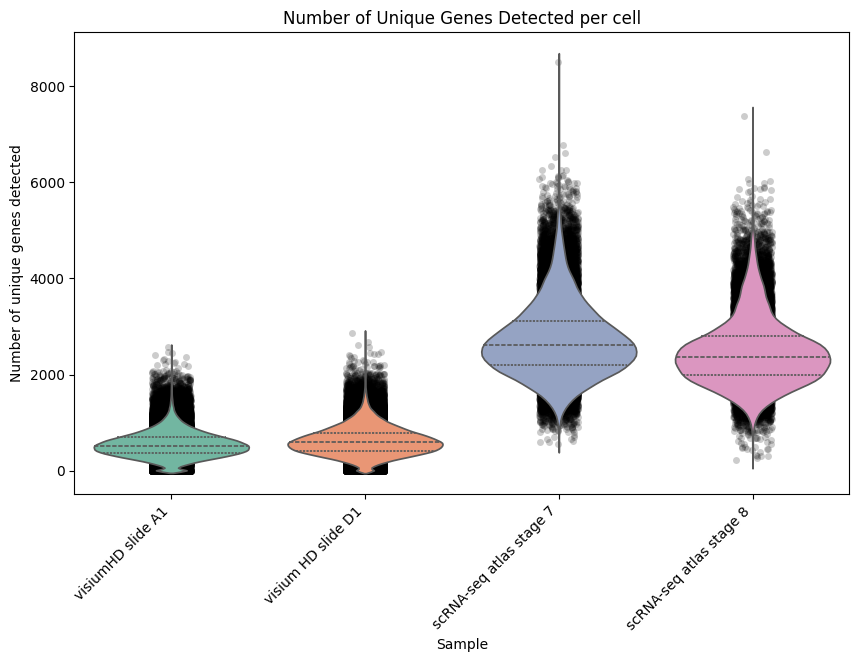

In [20]:
plt.figure(figsize=(10, 6))
sns.stripplot(data=df_long, x="Sample", y="Nb_genes", color="black", alpha=0.2, jitter=True, zorder=1)
sns.violinplot(data=df_long, x="Sample", y="Nb_genes", palette="Set2", inner="quartile")
plt.xticks(rotation=45, ha='right')  
plt.title("Number of Unique Genes Detected per cell")
plt.ylabel("Number of unique genes detected")
plt.show()

## Total counts in cell

In [21]:
# Extract n_genes_by_counts from each AnnData
data = []
for i, adata in enumerate(adata_list):
    data.append(adata.obs['total_counts'].values)

# Create a DataFrame with sample names
df = pd.DataFrame(data).T
df.columns = ["visiumHD slide A1", "visium HD slide D1", "scRNA-seq atlas stage 7", "scRNA-seq atlas stage 8"] 

df_long = df.melt(var_name="Sample", value_name="Total_counts")
df_long=df_long.dropna(axis=0)

/tmp/ipykernel_3088901/4097503792.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x="Sample", y="Total_counts", palette="Set2", inner="quartile")


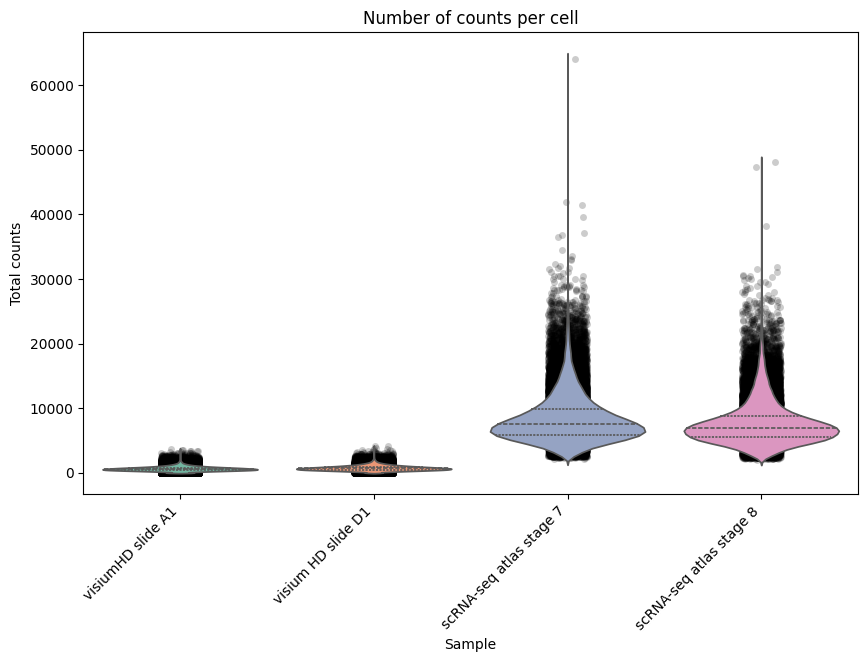

In [22]:
plt.figure(figsize=(10, 6))
sns.stripplot(data=df_long, x="Sample", y="Total_counts", color="black", alpha=0.2, jitter=True, zorder=1)
sns.violinplot(data=df_long, x="Sample", y="Total_counts", palette="Set2", inner="quartile")
plt.xticks(rotation=45, ha='right')  
plt.title("Number of counts per cell")
plt.ylabel("Total counts")
plt.show()

### Proportions Comparison

In [23]:
# Nb of cells
nb_cells_A1=adata_A1.n_obs
nb_cells_D1=adata_D1.n_obs

nb_cells_pcw8=atlas_stage8.n_obs
nb_cells_pcw7=atlas_stage7.n_obs

# Nb of genes
nb_genes_A1=adata_A1.n_vars
nb_genes_D1=adata_D1.n_vars

nb_genes_pcw8=atlas_stage8.n_vars
nb_genes_pcw7=atlas_stage7.n_vars

In [24]:
# Ratio of total nb of cells per technology
(nb_cells_A1+nb_cells_D1)/(nb_cells_pcw8+nb_cells_pcw7)

# Note: it's the same as ratio of avg nb of cells per technology (because (a/b)/(c/d) = (ac/bd) )
# ((nb_cells_A1+nb_cells_D1)/2) / ((nb_cells_pcw8+nb_cells_pcw7)/2)

4.387392352738546

In [30]:
# Ratio of avg unique nb of features per cell 
# be careful, I inverted the numerator and denominator on purpose
(avg_unique_genes_per_cell_stage7+avg_unique_genes_per_cell_stage8) / (avg_unique_genes_per_cell_A1+avg_unique_genes_per_cell_D1) 

4.462349523574771

In [31]:
# Ratio of avg counts per cell
# be careful, I inverted the numerator and denominator on purpose
(avg_counts_per_cell_stage7+avg_counts_per_cell_stage8)/(avg_counts_per_cell_A1+avg_counts_per_cell_D1) 

11.810473480287385